# **Import Libraries**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from math import floor
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix)
print("Import Done boss")

Import Done boss


# **Data Exploration**

## *Load the Data*

In [2]:
file_path = input("Enter the File Path: ")
df = pd.read_csv(file_path)
print('Data Loaded Boss')

Data Loaded Boss


## *Exploration*

In [3]:
print(f"The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} duplicates")

The dataset have 32300 Rows and 10 columns with 299 duplicates


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   session_duration_min  31655 non-null  str    
 1   pages_viewed          31655 non-null  float64
 2   cart_value            31654 non-null  float64
 3   prev_purchases        31653 non-null  float64
 4   discount_percent      31654 non-null  float64
 5   device_type           31655 non-null  float64
 6   day_of_week           31657 non-null  float64
 7   bounce_rate           31654 non-null  float64
 8   loyalty_score         31649 non-null  float64
 9   made_purchase         32300 non-null  int64  
dtypes: float64(8), int64(1), str(1)
memory usage: 2.6 MB


In [5]:
df.head()

,session_duration_min,pages_viewed,cart_value,prev_purchases,discount_percent,device_type,day_of_week,bounce_rate,loyalty_score,made_purchase
0,67.0,36.0,2632.33,8.0,42.8,2.0,6.0,0.691,76.0,1
1,87.0,45.0,655.80,5.0,8.6,0.0,6.0,0.424,69.0,0
2,115.0,42.0,3419.47,1.0,7.1,NaN,4.0,0.090,84.0,1
3,90.0,23.0,3593.45,1.0,35.4,0.0,6.0,0.322,27.0,0
4,67.0,42.0,1454.89,18.0,13.3,1.0,2.0,0.691,3.0,0


In [6]:
df.describe()

,pages_viewed,cart_value,prev_purchases,discount_percent,device_type,day_of_week,bounce_rate,loyalty_score,made_purchase
count,31655.000000,31654.000000,31653.000000,31654.000000,31655.000000,31657.000000,31654.000000,31649.000000,32300.000000
mean,25.144085,2513.634048,9.475437,25.145587,0.992545,2.990966,0.502242,49.112768,0.503839
std,14.076242,1440.054270,5.768974,14.438897,0.816798,2.001558,0.290431,28.768134,0.499993
min,1.000000,-200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,1271.957500,4.000000,12.600000,0.000000,1.000000,0.252000,24.000000,0.000000
50%,25.000000,2523.595000,9.000000,25.300000,1.000000,3.000000,0.501000,49.000000,1.000000
75%,37.000000,3764.992500,14.000000,37.600000,2.000000,5.000000,0.754000,74.000000,1.000000
max,49.000000,4999.600000,19.000000,150.000000,2.000000,6.000000,5.000000,200.000000,1.000000


In [7]:
print("NaN values in the dataset is: ")
print(df.isna().sum())

NaN values in the dataset is: 
session_duration_min    645
pages_viewed            645
cart_value              646
prev_purchases          647
discount_percent        646
device_type             645
day_of_week             643
bounce_rate             646
loyalty_score           651
made_purchase             0
dtype: int64


# **Data Cleaning**

## **Create Copy**

In [18]:
df_copy = df.copy()
print("Copy created boss")

Copy created boss


## **Datatype**

In [19]:
df_copy['session_duration_min'] = df_copy['session_duration_min'].replace('_err','',regex=True).astype('float')

## **Impossible values**

In [20]:
df_copy.loc[df_copy['session_duration_min']<=0,'session_duration_min'] = np.nan

df_copy.loc[df_copy['cart_value']<0,'cart_value'] = np.nan

df_copy.loc[df_copy['discount_percent']>50,'discount_percent'] = np.nan

df_copy.loc[df_copy['bounce_rate']>1,'bounce_rate'] = np.nan

df_copy.loc[df_copy['loyalty_score']>100,'loyalty_score'] = np.nan

## **Dulpicates**

In [23]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 300
After: 0


## **NaN Values**

### *Fill Them*

In [25]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())
NaN_columns = df_copy.columns.tolist()
NaN_columns.remove('made_purchase')
for col in NaN_columns:
    df_copy[col] = df_copy[col].fillna(floor(df_copy[col].median()))
print("NaN values in the Dataset after filling is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
session_duration_min    641
pages_viewed            640
cart_value              641
prev_purchases          640
discount_percent        641
device_type             640
day_of_week             640
bounce_rate             641
loyalty_score           641
made_purchase             0
dtype: int64
NaN values in the Dataset after filling is: 
session_duration_min    0
pages_viewed            0
cart_value              0
prev_purchases          0
discount_percent        0
device_type             0
day_of_week             0
bounce_rate             0
loyalty_score           0
made_purchase           0
dtype: int64


### *Drop them*

In [ ]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())
df_copy.dropna(inplace=True)
print("NaN values in the Dataset after filling is: ")
print(df_copy.isna().sum())

# **Data Preperation**

In [27]:
X = df_copy[['session_duration_min',
 'pages_viewed',
 'cart_value',
 'prev_purchases',
 'discount_percent',
 'device_type',
 'day_of_week',
 'bounce_rate',
 'loyalty_score']]

y = df_copy['made_purchase']

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (32000, 9)
y Shape: (32000,)


In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 train_size=0.8,
                                                 random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f'y_train Shape: {y_train.shape}')
print(f'X_test Shape:  {X_test.shape}')
print(f'y_test Shape:  {y_test.shape}')

X_train shape: (25600, 9)
y_train Shape: (25600,)
X_test Shape:  (6400, 9)
y_test Shape:  (6400,)


# **Model**

## **Train**

In [40]:
model = RandomForestClassifier(max_depth=6,
                               n_estimators=140,
                               n_jobs=-1,
                               min_samples_split=100,
                               min_samples_leaf=50,
                               oob_score=True,
                               random_state=42)

model.fit(X_train, y_train)
print("Model trained ✅")

Model trained ✅


## **OOB score**

In [41]:
print(f"OOB Score: {model.oob_score_:.4f}")

OOB Score: 0.7570


## **Test**

In [42]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

           0       0.76      0.77      0.76      3113
           1       0.78      0.77      0.77      3287

    accuracy                           0.77      6400
   macro avg       0.77      0.77      0.77      6400
weighted avg       0.77      0.77      0.77      6400

Accuracy: 0.7677


## **Features Importance**

                Feature  Importance
3        prev_purchases      0.3787
0  session_duration_min      0.2046
7           bounce_rate      0.1389
8         loyalty_score      0.1185
4      discount_percent      0.0798
2            cart_value      0.0459
1          pages_viewed      0.0312
6           day_of_week      0.0018
5           device_type      0.0006


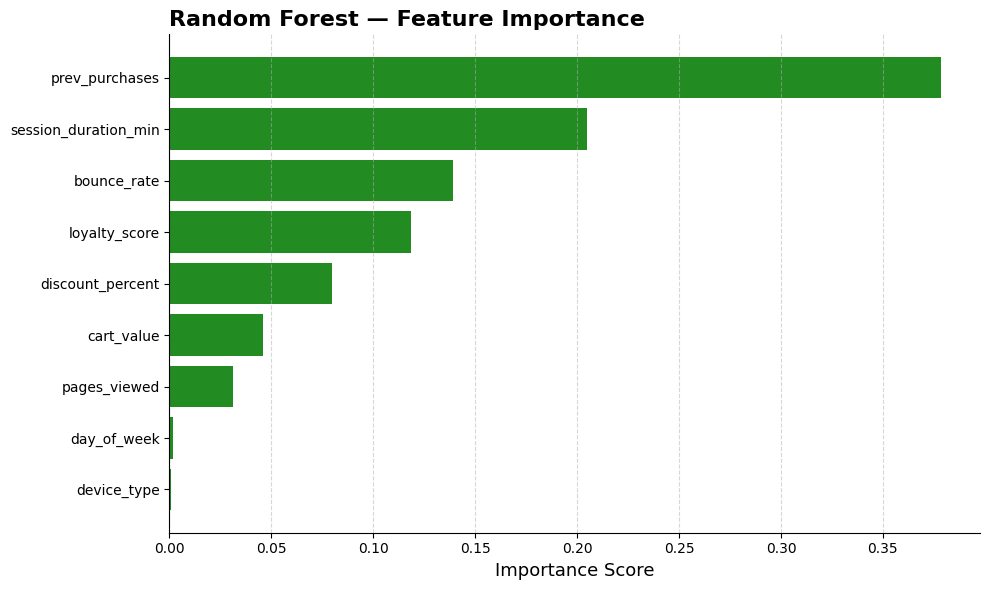

In [43]:
importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': model.feature_importances_.round(4)
}).sort_values('Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'],
         importance_df['Importance'],
         color='forestgreen')
ax = plt.gca()
ax.invert_yaxis()
ax.spines[['right','top']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Importance Score', fontsize=13)
plt.title('Random Forest — Feature Importance',
          fontweight='bold', fontsize=16, loc='left')
plt.tight_layout()
plt.show()

## **Gap**

In [44]:
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")
print(f"OOB Score:         {model.oob_score_:.4f}")

Training Accuracy: 0.7725
Testing Accuracy:  0.7677
Gap:               0.0049
OOB Score:         0.7570


## **How many tree is enough**

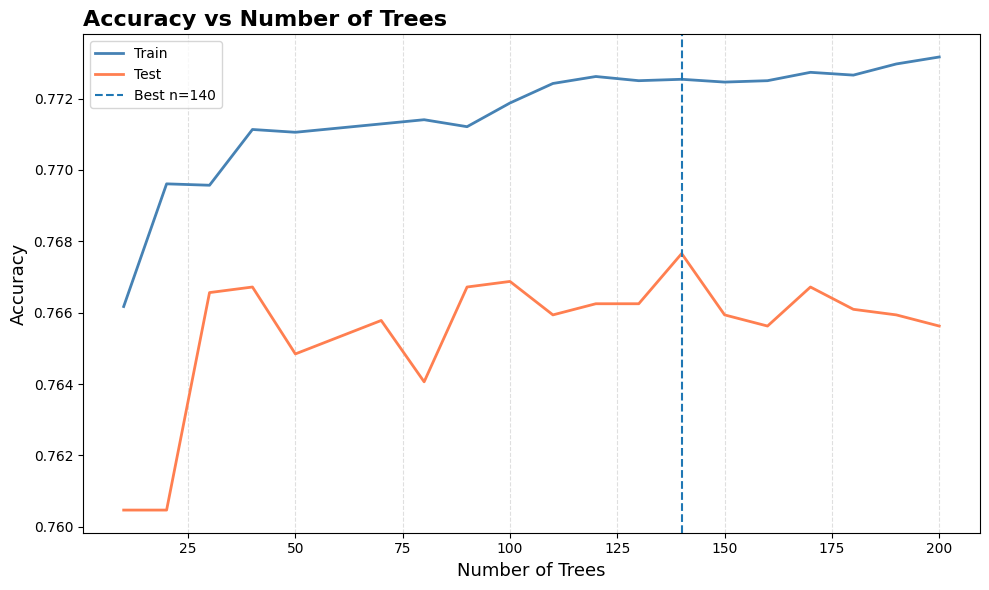

In [46]:
train_scores = []
test_scores  = []
tree_range   = range(10, 201, 10)

for n in tree_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1,max_depth=6,min_samples_split=100,min_samples_leaf=50)
    rf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, rf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(tree_range, train_scores, label='Train', color='steelblue', linewidth=2)
plt.plot(tree_range, test_scores,  label='Test',  color='coral',     linewidth=2)
plt.xlabel('Number of Trees', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Accuracy vs Number of Trees',
          fontweight='bold', fontsize=16, loc='left')
ax = plt.gca()
ax.xaxis.grid(True,linestyle='--',alpha=0.4)

best_index = np.argmax(test_scores)
best_n = tree_range[best_index]
best_score = test_scores[best_index]
plt.axvline(best_n, linestyle='--', label=f'Best n={best_n}')

plt.legend()
plt.tight_layout()
plt.show()

# **Chart**

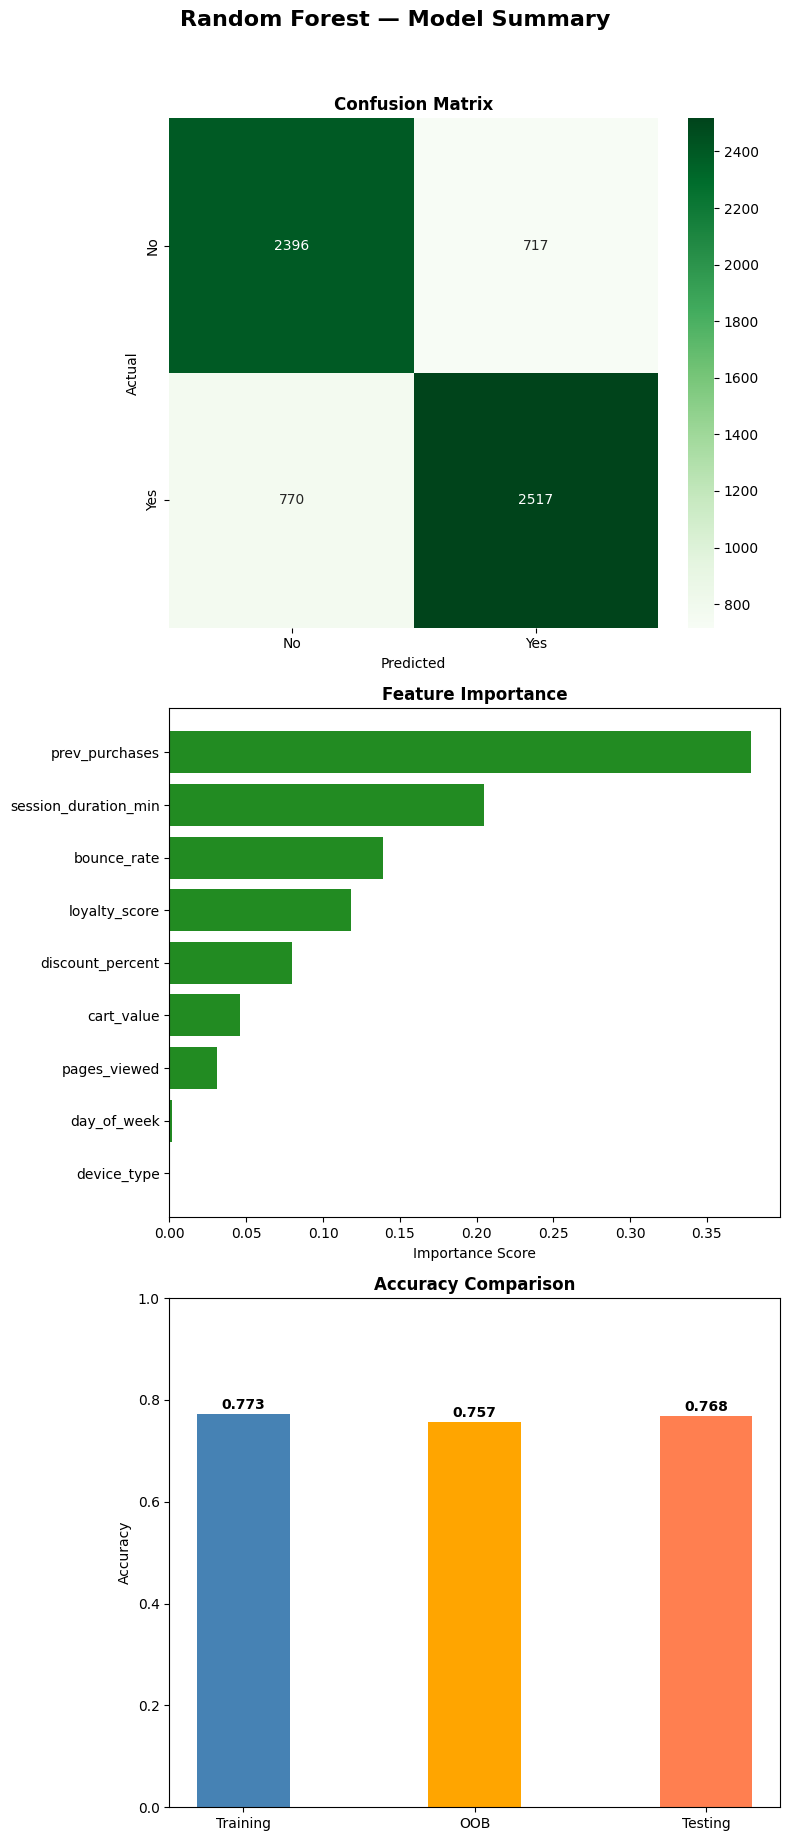

In [47]:
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — Feature Importance
imp = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance')
axes[1].barh(imp['Feature'], imp['Importance'], color='forestgreen')
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

# Plot 3 — Train vs Test vs OOB
labels = ['Training', 'OOB', 'Testing']
scores = [train_acc, model.oob_score_, test_acc]
colors = ['steelblue', 'orange', 'coral']
axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Accuracy Comparison', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.suptitle('Random Forest — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()